<a href="https://colab.research.google.com/github/NeoByteVoyager/PytorchLearning/blob/main/ML/BayesClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 朴素贝叶斯
是一种基于**贝叶斯规则**和**条件独立假设**的分类算法  
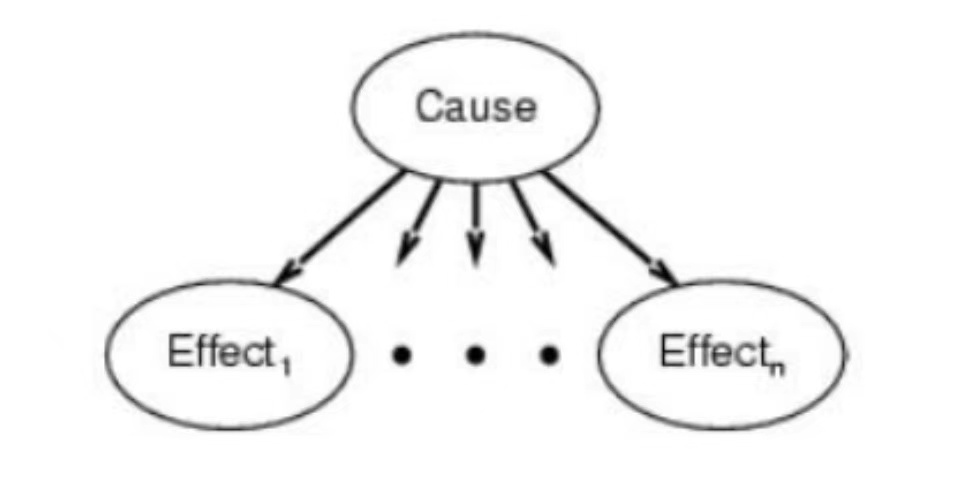

## 基本思想

通过计算**给定样本特征对各个类别的条件概率**来预测分类，选择**条件概率最大项**对应的类别作为样本的预测类别  

## 贝叶斯分类的流程

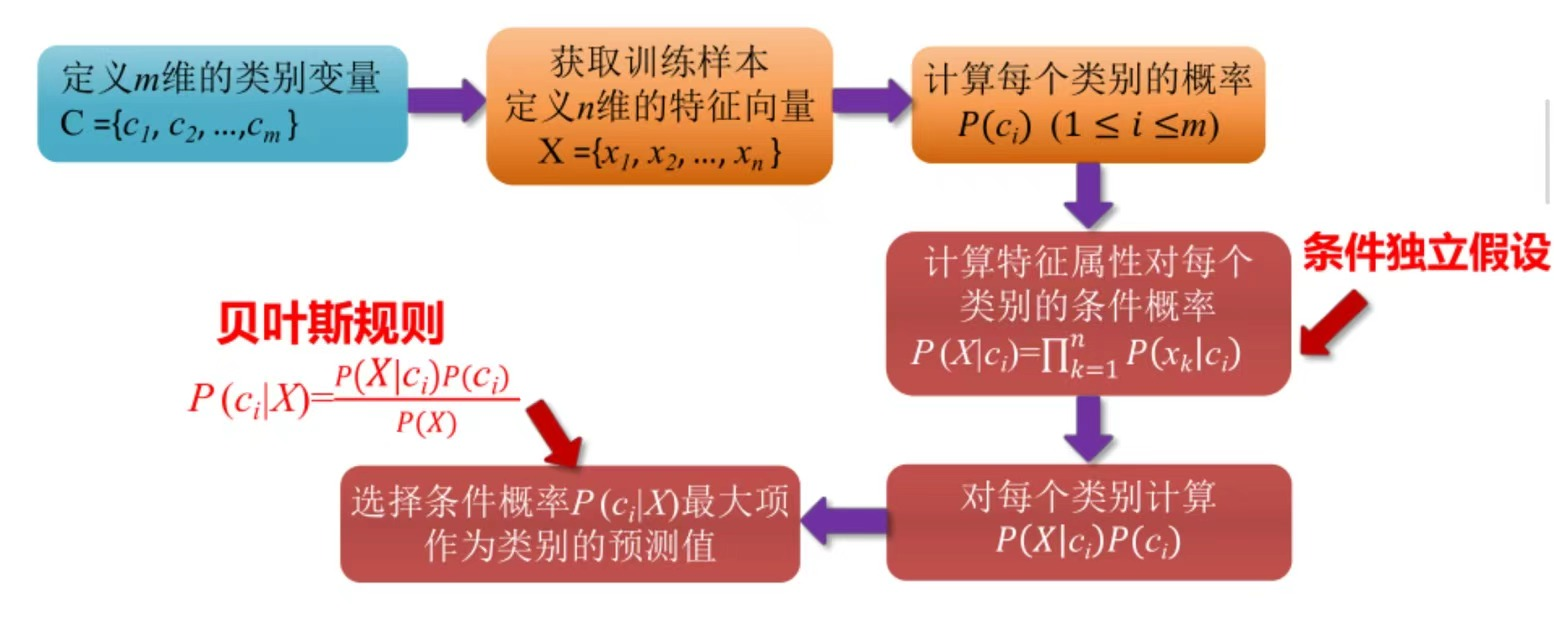



## 西瓜分类器（朴素贝叶斯）
### 目标
- 掌握贝叶斯预测流程
- 掌握贝叶斯预测流程  
### 训练流程
主要是计算各种**条件概率**。下表为一组西瓜数据:
|编号|颜色|声音|纹理|是否为好瓜|  
|---|---|---|---|---|
|1|绿|清脆|清晰|是|
|2|黄|浑厚|模糊|否|
|3|绿|浑厚|模糊|是|
|4|绿|清脆|清晰|是|
|5|黄|浑厚|模糊|是|
|6|绿|清脆|清晰|否|


In [21]:
import numpy as np


class NaiveBayesClassifier(object):
    def __init__(self):
        '''
        self.label_prob表示每种类别在数据中出现的概率
        例如，{0:0.333, 1:0.667}表示数据中类别0出现的概率为0.333，类别1的概率为0.667
        '''
        self.label_prob = {}
        '''
        self.condition_prob表示每种类别确定的条件下各个特征出现的概率
        例如训练数据集中的特征为 [[2, 1, 1],
                              [1, 2, 2],
                              [2, 2, 2],
                              [2, 1, 2],
                              [1, 2, 3]]
        标签为[1, 0, 1, 0, 1]
        那么当标签为0时第0列的值为1的概率为0.5，值为2的概率为0.5;
        当标签为0时第1列的值为1的概率为0.5，值为2的概率为0.5;
        当标签为0时第2列的值为1的概率为0，值为2的概率为1，值为3的概率为0;
        当标签为1时第0列的值为1的概率为0.333，值为2的概率为0.666;
        当标签为1时第1列的值为1的概率为0.333，值为2的概率为0.666;
        当标签为1时第2列的值为1的概率为0.333，值为2的概率为0.333,值为3的概率为0.333;
        因此self.label_prob的值如下：
        {
            0:{
                0:{
                    1:0.5
                    2:0.5
                }
                1:{
                    1:0.5
                    2:0.5
                }
                2:{
                    1:0
                    2:1
                    3:0
                }
            }
            1:
            {
                0:{
                    1:0.333
                    2:0.666
                }
                1:{
                    1:0.333
                    2:0.666
                }
                2:{
                    1:0.333
                    2:0.333
                    3:0.333
                }
            }
        }
        '''
        self.condition_prob = {}
    def fit(self, feature, label):
        '''
        对模型进行训练，需要将各种概率分别保存在self.label_prob和self.condition_prob中
        :param feature: 训练数据集所有特征组成的ndarray
        :param label:训练数据集中所有标签组成的ndarray
        :return: 无返回
        '''


        #********* Begin *********#
        # 首先计算每个类别的先验概率
        unique_labels, counts = np.unique(label,return_counts=True)
        total_samples = len(label)
        for i in range(len(unique_labels)):
          self.label_prob[unique_labels[i]] = counts[i] / total_samples
          # print(unique_labels[i],self.label_prob[unique_labels[i]])

        # 然后计算条件概率
        for c in unique_labels:
          # 初始化每个类别字典
          self.condition_prob[c] = {}
          # 取出特征值等于c的数据
          feature_c = feature[label==c]
          # 特征值为c样本数
          total_c = len(feature_c)
          for col in range(feature.shape[1]):
            # 初始化每个特征字典
            self.condition_prob[c][col] = {}
            # 取出这一特征列的所有数据
            col_data=feature_c[:,col]
            unique_t,count_t=np.unique(col_data,return_counts=True)
            for i in range(len(unique_t)):
              self.condition_prob[c][col][unique_t[i]]=count_t[i]/total_c


        #********* End *********#


    def predict(self, feature):
        '''
        对数据进行预测，返回预测结果
        :param feature:测试数据集所有特征组成的ndarray
        :return:
        '''
        # ********* Begin *********#
        # 初始化返回结果
        res = []
        # 遍历每个测试特征值
        for i in range(feature.shape[0]):
          max_prob=0.0
          res_i=0
          # 开始计算每个类别下该特征的概率
          for c in self.label_prob:
            prob=self.label_prob[c]
            for col in range(feature.shape[1]):
              val=feature[i][col] # 要先判断刚训练的数据是否包含该数据
              if val in self.condition_prob[c][col]:
                prob*=self.condition_prob[c][col][val]
              else:
                prob=0
            # print(c,prob)
            if prob>max_prob:
              max_prob=prob
              res_i=c
          res.append(res_i)
        return res
        #********* End *********#
features=np.array([[2, 1, 1],
                              [1, 2, 2],
                              [2, 2, 2],
                              [2, 1, 2],
                              [1, 2, 3]])
labels=np.array([1, 0, 1, 0, 1])
classifer=NaiveBayesClassifier()
classifer.fit(features,labels)
print(classifer.condition_prob)
print(classifer.label_prob)
res=classifer.predict(features)
print(res)


{np.int64(0): {0: {np.int64(1): np.float64(0.5), np.int64(2): np.float64(0.5)}, 1: {np.int64(1): np.float64(0.5), np.int64(2): np.float64(0.5)}, 2: {np.int64(2): np.float64(1.0)}}, np.int64(1): {0: {np.int64(1): np.float64(0.3333333333333333), np.int64(2): np.float64(0.6666666666666666)}, 1: {np.int64(1): np.float64(0.3333333333333333), np.int64(2): np.float64(0.6666666666666666)}, 2: {np.int64(1): np.float64(0.3333333333333333), np.int64(2): np.float64(0.3333333333333333), np.int64(3): np.float64(0.3333333333333333)}}}
{np.int64(0): np.float64(0.4), np.int64(1): np.float64(0.6)}
[np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1)]
